<a href="https://colab.research.google.com/github/saiprasanthreddy/ml-things/blob/main/Find_Optimal_Threshold_For_Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
%matplotlib inline

from sklearn.datasets import make_classification

In [10]:
from sklearn.model_selection import train_test_split
x,y = make_classification(n_samples=2000,  n_classes=2,weights=[1,1], random_state=1)

In [11]:
x.shape

(2000, 20)

In [12]:
y


array([0, 0, 0, ..., 1, 1, 0])

In [13]:
X_train , X_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=1)

In [15]:
X_train.shape

(1400, 20)

In [16]:
X_test.shape

(600, 20)

In [17]:
y_train.shape

(1400,)

In [18]:
y_test.shape

(600,)

When building a machine learning model, we need to split our dataset into different parts for training and evaluation. This is crucial to ensure our model can generalize well to new, unseen data, rather than just memorizing the training data.

Here's why we use these four components:

### `X_train` (Training Features)

*   **What it is:** This contains the features (input variables) that your model will learn from during the training phase. It's a subset of your original dataset's independent variables.
*   **Why we use it:** The model 'sees' this data and adjusts its internal parameters (weights and biases) to find patterns and relationships that map the features to the target variable (`y_train`). This is where the model 'learns'.

### `y_train` (Training Target/Labels)

*   **What it is:** This contains the corresponding target variable (output or labels) for each observation in `X_train`. It's a subset of your original dataset's dependent variable.
*   **Why we use it:** During training, the model uses `y_train` to compare its predictions with the actual outcomes. This comparison allows the model to calculate its error and update its parameters to improve its accuracy. For example, if the model predicts '0' but `y_train` says '1', the model learns from this mistake.

### `X_test` (Testing Features)

*   **What it is:** This contains features that the model has **never seen** before. It's a separate subset of the independent variables.
*   **Why we use it:** After training, we use `X_test` to evaluate how well our model performs on new, unseen data. By feeding `X_test` to the trained model, we get its predictions for these new inputs.

### `y_test` (Testing Target/Labels)

*   **What it is:** This contains the true corresponding target variable (output or labels) for each observation in `X_test`.
*   **Why we use it:** We compare the predictions made by our trained model on `X_test` with the actual values in `y_test`. This comparison gives us an unbiased measure of the model's performance and its ability to generalize to new data. If the model performs well on `X_test` (meaning its predictions are close to `y_test`), it indicates a robust model.

### In Summary:

*   **Training Set (`X_train`, `y_train`):** Used to teach the model.
*   **Test Set (`X_test`, `y_test`):** Used to objectively evaluate the model's performance on data it hasn't seen during training.

This split helps us prevent **overfitting**, a common problem where a model performs very well on the training data but poorly on new data because it has simply memorized the training examples rather than learning general patterns.

In [19]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [20]:
## Apply RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
print('RF test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

RF train roc-auc: 1.0
RF test roc-auc: 0.9843277777777778


In [21]:
ytrain_pred

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [0.04, 0.96],
       ...,
       [0.98, 0.02],
       [1.  , 0.  ],
       [0.18, 0.82]])

In [22]:
from sklearn.linear_model import LogisticRegression
log_classifier=LogisticRegression()
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

Logistic train roc-auc: 0.9863589331232614
Logistic test roc-auc: 0.9885777777777777


In [23]:
from sklearn.ensemble import AdaBoostClassifier
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

Adaboost train roc-auc: 0.9926743552432595
Adaboost test roc-auc: 0.9794888888888889


In [27]:
from sklearn.neighbors import KNeighborsClassifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNeighboursclassifier train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNeighborsClassifier test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

KNeighboursclassifier train roc-auc: 0.981670071491109
KNeighborsClassifier test roc-auc: 0.9426111111111111


In [28]:
pred=[]
for model in [rf_model,log_classifier,ada_classifier,knn_classifier]:
    pred.append(pd.Series(model.predict_proba(X_test)[:,1]))
final_prediction=pd.concat(pred,axis=1).mean(axis=1)
print('Ensemble test roc-auc: {}'.format(roc_auc_score(y_test,final_prediction)))

Ensemble test roc-auc: 0.9854222222222222


In [29]:
pd.concat(pred,axis=1)

,0,1,2,3
0,0.99,0.991873,0.669528,1.0
1,0.03,0.000008,0.316455,0.0
2,0.98,0.966763,0.632138,0.8
3,0.92,0.761896,0.533171,0.8
4,0.68,0.779209,0.440650,0.4
...,...,...,...,...
595,0.01,0.024263,0.321128,0.0
596,0.05,0.000003,0.262749,0.0
597,0.98,0.984400,0.605074,1.0
598,0.04,0.001157,0.266081,0.2


In [30]:
final_prediction

,0
0,0.912850
1,0.086616
2,0.844725
3,0.753767
4,0.574965
...,...
595,0.088848
596,0.078188
597,0.892368
598,0.126810


In [32]:
fpr, tpr, thresholds = roc_curve(y_test, final_prediction)
thresholds

array([       inf, 0.92689995, 0.90625123, 0.90585577, 0.82291229,
       0.82158135, 0.8050967 , 0.80491304, 0.77174044, 0.77087021,
       0.74705102, 0.74609565, 0.74420068, 0.73945217, 0.68908259,
       0.68247295, 0.59446969, 0.58883457, 0.57830144, 0.57550184,
       0.56706678, 0.55348082, 0.54659348, 0.53845293, 0.50330504,
       0.47369513, 0.44446984, 0.42980819, 0.42348027, 0.36581505,
       0.35292692, 0.34774911, 0.33748471, 0.22310355, 0.21865762,
       0.19543781, 0.19468852, 0.18324728, 0.18159164, 0.08884765,
       0.08877288, 0.05402849])

In [33]:
from sklearn.metrics import accuracy_score
accuracy_ls = []
for thres in thresholds:
    y_pred = np.where(final_prediction>thres,1,0)
    accuracy_ls.append(accuracy_score(y_test, y_pred, normalize=True))

accuracy_ls = pd.concat([pd.Series(thresholds), pd.Series(accuracy_ls)],
                        axis=1)
accuracy_ls.columns = ['thresholds', 'accuracy']
accuracy_ls.sort_values(by='accuracy', ascending=False, inplace=True)
accuracy_ls.head()

,thresholds,accuracy
26,0.444470,0.960000
27,0.429808,0.960000
28,0.423480,0.958333
25,0.473695,0.958333
24,0.503305,0.956667


In [34]:
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()


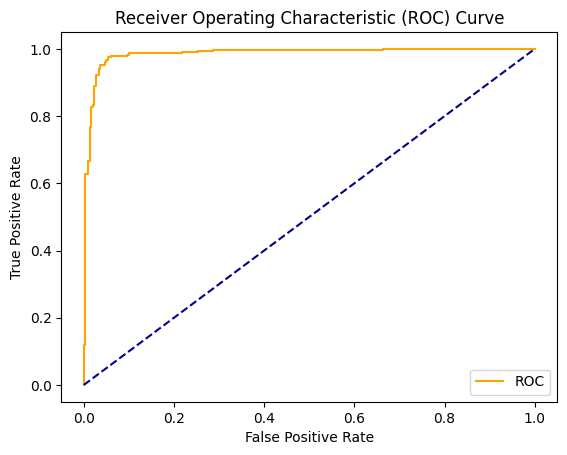

In [35]:
plot_roc_curve(fpr,tpr)